**Marketing Data Analysis and Revenue Prediction using Python and Machine Learning**

## Objective

The objective of this project is to analyze marketing campaign performance using Python and Machine Learning. The project aims to identify the best-performing marketing channels, understand customer engagement, analyze revenue and advertising spend, and build a predictive model to estimate revenue based on campaign performance.

## Data Source

The dataset used in this project is taken from the YBI Foundation GitHub Repository.

Dataset Link:
https://raw.githubusercontent.com/YBIFoundation/ProjectDataSet/main/Marketing%20Data%20Analysis.csv

In [32]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [33]:
# Read Dataset

df = pd.read_csv("https://raw.githubusercontent.com/YBIFoundation/ProjectDataSet/main/Marketing%20Data%20Analysis.csv")

In [34]:
df.head()

,Unnamed: 0,Date,Channel,Region,Ad_Spend,Impressions,Clicks,Conversions,Revenue,CTR,Conversion_Rate
0,0,2025-01-01,Facebook,East,35072,324422,12194,1177,487278,4,10
1,1,2025-01-01,YouTube,North,15612,434523,5654,2927,2517220,1,52
2,2,2025-01-01,Instagram,East,5582,65898,9991,761,318859,15,8
3,3,2025-01-02,YouTube,East,21320,105984,7077,2505,2367225,7,35
4,4,2025-01-04,YouTube,South,10838,298801,16150,2179,1717052,5,13


In [35]:
df.shape

(1000, 11)

In [36]:
df.columns

Index(['Unnamed: 0', 'Date', 'Channel', 'Region', 'Ad_Spend', 'Impressions',
       'Clicks', 'Conversions', 'Revenue', 'CTR', 'Conversion_Rate'],
      dtype='object')

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       1000 non-null   int64 
 1   Date             1000 non-null   object
 2   Channel          1000 non-null   object
 3   Region           1000 non-null   object
 4   Ad_Spend         1000 non-null   int64 
 5   Impressions      1000 non-null   int64 
 6   Clicks           1000 non-null   int64 
 7   Conversions      1000 non-null   int64 
 8   Revenue          1000 non-null   int64 
 9   CTR              1000 non-null   int64 
 10  Conversion_Rate  1000 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 86.1+ KB


In [38]:
df.describe()

,Unnamed: 0,Ad_Spend,Impressions,Clicks,Conversions,Revenue,CTR,Conversion_Rate
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1.000000e+03,1000.000000,1000.000000
mean,499.500000,27373.362000,263305.952000,10205.10800,1520.087000,9.165629e+05,7.749000,28.621000
std,288.819436,12908.653881,139791.528738,5741.32884,862.106435,6.606403e+05,13.752714,43.401671
min,0.000000,5102.000000,10748.000000,533.00000,54.000000,1.956000e+04,0.000000,0.000000
25%,249.750000,16286.000000,147697.000000,5090.25000,791.750000,3.845415e+05,2.000000,7.750000
50%,499.500000,27914.500000,266647.000000,10208.50000,1475.000000,7.477765e+05,4.000000,15.000000
75%,749.250000,38630.000000,382078.250000,15254.75000,2262.000000,1.301754e+06,7.000000,29.000000
max,999.000000,49930.000000,499747.000000,19982.00000,2998.000000,2.810090e+06,151.000000,464.000000


In [39]:
df.isnull().sum()

,0
Unnamed: 0,0
Date,0
Channel,0
Region,0
Ad_Spend,0
Impressions,0
Clicks,0
Conversions,0
Revenue,0
CTR,0


In [40]:
df.duplicated().sum()

np.int64(0)

**Data Visualization**

Revenue by Marketing Channel

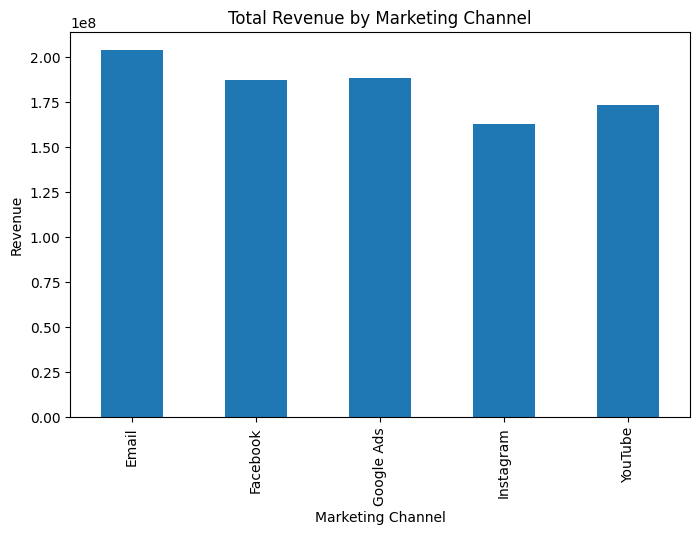

In [41]:
revenue_by_channel = df.groupby('Channel')['Revenue'].sum()

plt.figure(figsize=(8,5))
revenue_by_channel.plot(kind='bar')

plt.title('Total Revenue by Marketing Channel')
plt.xlabel('Marketing Channel')
plt.ylabel('Revenue')

plt.show()

This chart shows the total revenue generated by each marketing channel. It helps identify which marketing platform contributes the highest revenue and supports better budget allocation for future campaigns.

Ad Spend by Marketing Channel

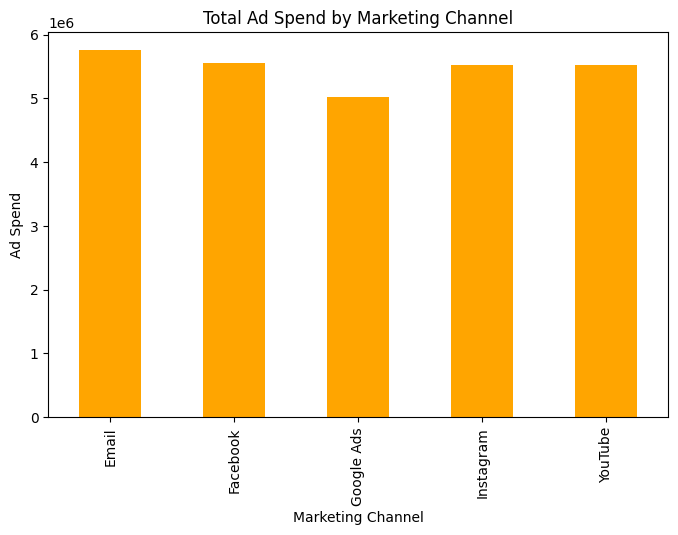

In [42]:
ad_spend = df.groupby('Channel')['Ad_Spend'].sum()

plt.figure(figsize=(8,5))
ad_spend.plot(kind='bar', color='orange')

plt.title('Total Ad Spend by Marketing Channel')
plt.xlabel('Marketing Channel')
plt.ylabel('Ad Spend')

plt.show()

This chart shows the total advertising spend across different marketing channels. It helps identify where the company invests the most in marketing campaigns and supports budget optimization decisions.

Total Clicks by Marketing Channel

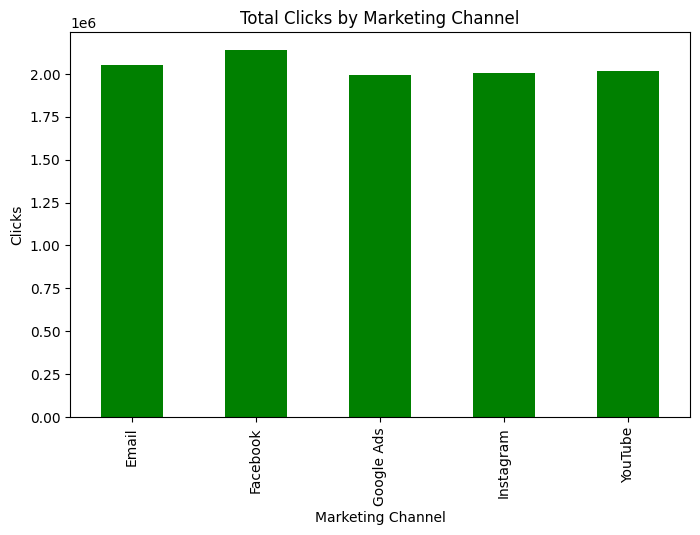

In [43]:
clicks = df.groupby('Channel')['Clicks'].sum()

plt.figure(figsize=(8,5))
clicks.plot(kind='bar', color='green')

plt.title('Total Clicks by Marketing Channel')
plt.xlabel('Marketing Channel')
plt.ylabel('Clicks')

plt.show()

This visualization compares the total number of clicks generated by each marketing channel. A higher number of clicks indicates stronger customer engagement and greater interest in marketing campaigns.

Total Conversions by Marketing Channel

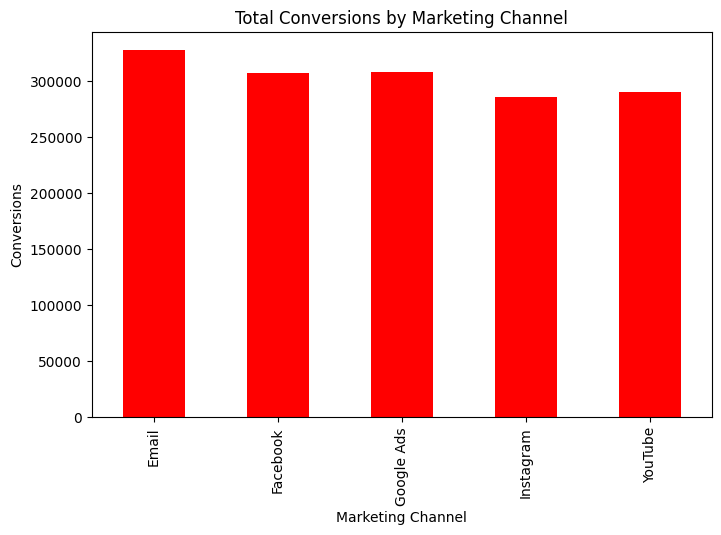

In [44]:
conversion = df.groupby('Channel')['Conversions'].sum()

plt.figure(figsize=(8,5))
conversion.plot(kind='bar', color='red')

plt.title('Total Conversions by Marketing Channel')
plt.xlabel('Marketing Channel')
plt.ylabel('Conversions')

plt.show()

This chart compares the total conversions across all marketing channels. It helps determine which platform is most effective in converting potential customers into actual customers.

**Data Preprocessing**

Define Target Variable (y) and Feature Variables (X)

In this project, the target variable is **Revenue**, as our objective is to predict the revenue generated from marketing campaigns. The remaining marketing-related features are used as input variables to train the machine learning model.

In [45]:
y = df['Revenue']

X = df[['Ad_Spend',
        'Impressions',
        'Clicks',
        'Conversions']]

In [46]:
X.head()

,Ad_Spend,Impressions,Clicks,Conversions
0,35072,324422,12194,1177
1,15612,434523,5654,2927
2,5582,65898,9991,761
3,21320,105984,7077,2505
4,10838,298801,16150,2179


In [47]:
y.head()


,Revenue
0,487278
1,2517220
2,318859
3,2367225
4,1717052


Train Test Split

The dataset is divided into two parts: the training set and the testing set. The training data is used to train the machine learning model, while the testing data is used to evaluate how well the model performs on unseen data.

In [48]:
from sklearn.model_selection import train_test_split

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [50]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (800, 4)
Testing Features: (200, 4)
Training Target: (800,)
Testing Target: (200,)


Observation

The dataset was successfully divided into training and testing datasets. About 80% of the data was used to train the model, while 20% was reserved to evaluate the model's performance on unseen data.

**Modeling**

A Linear Regression model is used in this project because the target variable (Revenue) is a continuous numerical value. The model learns the relationship between advertising metrics and revenue.

In [51]:
from sklearn.linear_model import LinearRegression

In [52]:
model = LinearRegression()

In [53]:
model.fit(X_train, y_train)

LinearRegression()

The Linear Regression model was successfully trained using the training dataset. The model has learned the relationship between the input features and the target variable.

**Prediction**

The trained Linear Regression model is used to predict the revenue for the testing dataset.

In [54]:
y_pred = model.predict(X_test)

In [55]:
comparison = pd.DataFrame({
    'Actual Revenue': y_test.values,
    'Predicted Revenue': y_pred
})

comparison.head(10)

,Actual Revenue,Predicted Revenue
0,531665,5.298178e+05
1,750464,1.584282e+06
2,2026461,1.777519e+06
3,1143818,9.309600e+05
4,246512,1.809619e+05
5,167808,1.171028e+05
6,613200,5.061561e+05
7,569972,7.468380e+05
8,907888,1.725742e+06
9,1090777,7.888524e+05


The model performance is evaluated using Mean Absolute Percentage Error (MAPE). A lower MAPE value indicates better prediction accuracy.

**Model Evaluation**

In [57]:
from sklearn.metrics import mean_absolute_percentage_error

In [58]:
mean_absolute_percentage_error(y_test, y_pred)

0.4466058234692478

The model was evaluated using Mean Absolute Percentage Error (MAPE). The obtained MAPE value is **0.4466**, which means the model has an average prediction error of approximately **44.66%**. This evaluation provides an estimate of how accurately the model predicts revenue.

**Explanation**

This project focuses on analyzing marketing campaign data using Python and Machine Learning.

First, the dataset was imported and explored using the Pandas library. Data preprocessing techniques such as checking missing values and duplicate records were performed to ensure data quality.

Various visualizations were created using Matplotlib to understand the performance of different marketing channels based on advertising spend, impressions, clicks, conversions, and revenue.

After data analysis, a Linear Regression model was developed to predict revenue. The dataset was divided into training and testing sets, and the model was trained using marketing features such as Ad Spend, Impressions, Clicks, and Conversions.

Finally, the model generated revenue predictions and was evaluated using Mean Absolute Percentage Error (MAPE). The project demonstrates how machine learning can help businesses estimate future revenue and support data-driven marketing decisions.

This project successfully analyzed marketing campaign performance using Python and Machine Learning. Various visualizations were created to understand customer engagement, advertising spend, conversions, and revenue. A Linear Regression model was trained to predict revenue using marketing metrics. The project demonstrates how data analytics and machine learning can support better marketing decisions and future campaign planning.